In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
%cd /content/drive/MyDrive/IS 296

/content/drive/MyDrive/IS 296


In [12]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [13]:
path = '/content/drive/MyDrive/IS 296/Sleep_health_and_lifestyle_dataset.csv'
table_data = Table.read_table(path)
table_data

Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,nan
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,nan
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,nan
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,nan
9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,nan
10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,nan


In [14]:
table_rows_num = table_data.num_rows
table_rows_num

374

In [15]:
table_columns_num = table_data.num_columns
table_columns_num

13

# Question 1: **How do differing job fields impact physical activity levels?**


In [16]:
occupations = table_data.select('Occupation', 'Physical Activity Level')
occupations

Occupation,Physical Activity Level
Software Engineer,42
Doctor,60
Doctor,60
Sales Representative,30
Sales Representative,30
Software Engineer,30
Teacher,40
Doctor,75
Doctor,75
Doctor,75


In [17]:
service_jobs = occupations.where('Occupation', are.contained_in(['Sales Representative', 'Teacher', 'Salesperson']))
healthcare_jobs = occupations.where('Occupation', are.contained_in(['Doctor', 'Nurse', 'Scientist']))
technology_jobs = occupations.where('Occupation', are.contained_in(['Engineer', 'Software Engineer']))
business_jobs = occupations.where('Occupation', are.contained_in(['Lawyer', 'Accountant']))

In [18]:
service_jobs_activity_average = np.average(service_jobs.column('Physical Activity Level'))
healthcare_jobs_activity_average = np.average(healthcare_jobs.column('Physical Activity Level'))
business_jobs_activity_average = np.average(business_jobs.column('Physical Activity Level'))
technology_jobs_activity_average = np.average(technology_jobs.column('Physical Activity Level'))

In [19]:
fields_table = Table().with_columns(
    'Job Field', ['Service', 'Healthcare', 'Business', 'Technology'],
    'Physical Activity Average', [service_jobs_activity_average, healthcare_jobs_activity_average, business_jobs_activity_average, technology_jobs_activity_average]
)
fields_table

Job Field,Physical Activity Average
Service,44.9324
Healthcare,66.4257
Business,65
Technology,51.6269


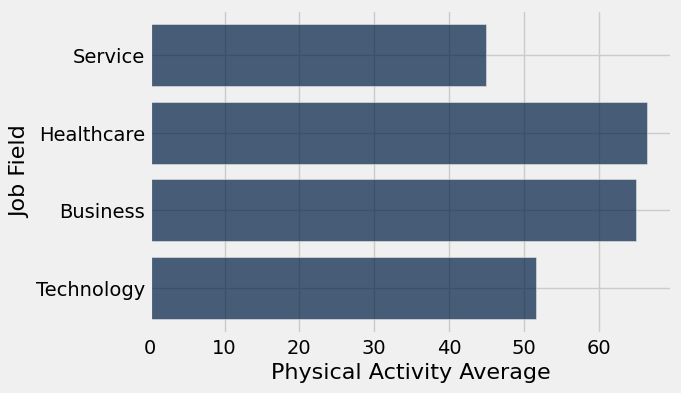

In [20]:
fields_table.barh('Job Field')

## Question 2: **Does Gender Impact the Doctor Lifestyle?**

In [21]:
gender_stress_table = table_data.select('Gender', 'Occupation', 'Stress Level')
gender_stress_table

Gender,Occupation,Stress Level
Male,Software Engineer,6
Male,Doctor,8
Male,Doctor,8
Male,Sales Representative,8
Male,Sales Representative,8
Male,Software Engineer,8
Male,Teacher,7
Male,Doctor,6
Male,Doctor,6
Male,Doctor,6


In [22]:
gender_sleep_table = table_data.select('Gender', 'Occupation', 'Quality of Sleep')
gender_sleep_table

Gender,Occupation,Quality of Sleep
Male,Software Engineer,6
Male,Doctor,6
Male,Doctor,6
Male,Sales Representative,4
Male,Sales Representative,4
Male,Software Engineer,4
Male,Teacher,6
Male,Doctor,7
Male,Doctor,7
Male,Doctor,7


In [23]:
female_filter = gender_sleep_table.where('Gender', are.contained_in(['Female']))
female_stats_sleep = female_filter.where('Occupation', are.contained_in(['Doctor']))
female_stats_sleep

Gender,Occupation,Quality of Sleep
Female,Doctor,9
Female,Doctor,9


In [24]:
female_filter = gender_stress_table.where('Gender', are.contained_in(['Female']))
female_stats_stress = female_filter.where('Occupation', are.contained_in(['Doctor']))
female_stats_stress

Gender,Occupation,Stress Level
Female,Doctor,3
Female,Doctor,3


In [25]:
female_stats_avg_sleep = np.average(female_stats_sleep.column('Quality of Sleep'))
female_stats_avg_stress = np.average(female_stats_stress.column('Stress Level'))

In [26]:
male_filter = gender_sleep_table.where('Gender', are.contained_in(['Male']))
male_stats_sleep = male_filter.where('Occupation', are.contained_in(['Doctor']))
male_stats_sleep

Gender,Occupation,Quality of Sleep
Male,Doctor,6
Male,Doctor,6
Male,Doctor,7
Male,Doctor,7
Male,Doctor,7
Male,Doctor,6
Male,Doctor,7
Male,Doctor,6
Male,Doctor,6
Male,Doctor,6


In [27]:
male_filter = gender_stress_table.where('Gender', are.contained_in(['Male']))
male_stats_stress = male_filter.where('Occupation', are.contained_in(['Doctor']))
male_stats_stress

Gender,Occupation,Stress Level
Male,Doctor,8
Male,Doctor,8
Male,Doctor,6
Male,Doctor,6
Male,Doctor,6
Male,Doctor,8
Male,Doctor,6
Male,Doctor,8
Male,Doctor,8
Male,Doctor,8


In [28]:
male_stats_avg_sleep = np.average(male_stats_sleep.column('Quality of Sleep'))
male_stats_avg_stress = np.average(male_stats_stress.column('Stress Level'))

In [29]:
sleep_stats_table = Table().with_columns(
    'Gender', ['Female', 'Male'],
    'Average Sleep Quality', [female_stats_avg_sleep, male_stats_avg_sleep]
)
sleep_stats_table

Gender,Average Sleep Quality
Female,9
Male,6.57971


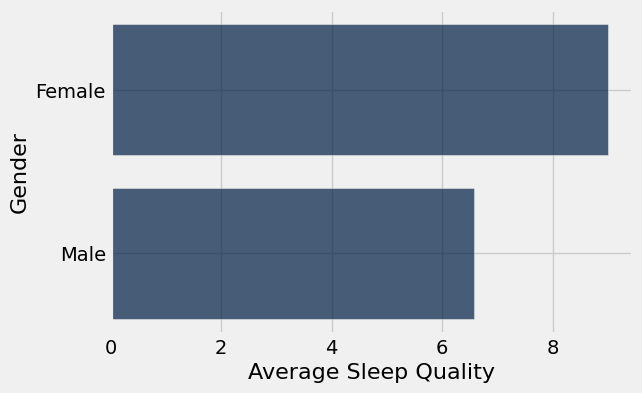

In [30]:
sleep_stats_table.barh('Gender')

In [31]:
stress_stats_table = Table().with_columns(
    'Gender', ['Female', 'Male'],
    'Stress Level', [female_stats_avg_stress, male_stats_avg_stress]
)
stress_stats_table

Gender,Stress Level
Female,3
Male,6.84058


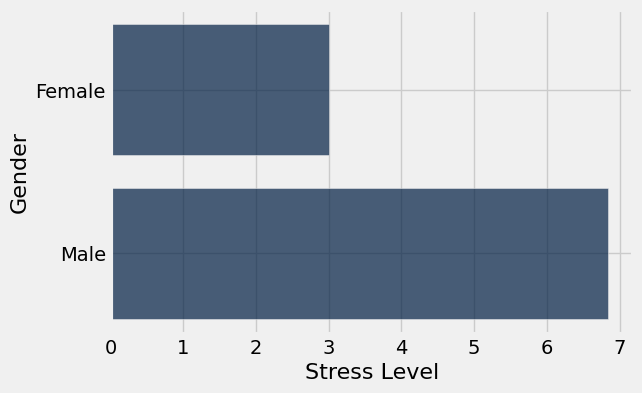

In [32]:
stress_stats_table.barh('Gender')

## Question 2.2: **Does this impact the doctor field or does this result happen in all job fields?**

In [33]:
female_filter_sleep = gender_sleep_table.where('Gender', are.contained_in(['Female']))
female_filter_sleep

Gender,Occupation,Quality of Sleep
Female,Nurse,5
Female,Nurse,5
Female,Nurse,5
Female,Nurse,5
Female,Nurse,8
Female,Scientist,6
Female,Scientist,6
Female,Scientist,4
Female,Scientist,4
Female,Accountant,8


In [34]:
female_filter_stress = gender_stress_table.where('Gender', are.contained_in(['Female']))
female_filter_stress

Gender,Occupation,Stress Level
Female,Nurse,7
Female,Nurse,7
Female,Nurse,7
Female,Nurse,7
Female,Nurse,4
Female,Scientist,6
Female,Scientist,6
Female,Scientist,8
Female,Scientist,8
Female,Accountant,4


In [35]:
male_filter_sleep = gender_sleep_table.where('Gender', are.contained_in(['Male']))
male_filter_sleep

Gender,Occupation,Quality of Sleep
Male,Software Engineer,6
Male,Doctor,6
Male,Doctor,6
Male,Sales Representative,4
Male,Sales Representative,4
Male,Software Engineer,4
Male,Teacher,6
Male,Doctor,7
Male,Doctor,7
Male,Doctor,7


In [36]:
male_filter_stress = gender_stress_table.where('Gender', are.contained_in(['Male']))
male_filter_stress

Gender,Occupation,Stress Level
Male,Software Engineer,6
Male,Doctor,8
Male,Doctor,8
Male,Sales Representative,8
Male,Sales Representative,8
Male,Software Engineer,8
Male,Teacher,7
Male,Doctor,6
Male,Doctor,6
Male,Doctor,6


In [37]:
sleep_filter_female = np.average(female_filter_sleep.column('Quality of Sleep'))
stress_filter_female = np.average(female_filter_stress.column('Stress Level'))

sleep_filter_male = np.average(male_filter_sleep.column('Quality of Sleep'))
stress_filter_male = np.average(male_filter_stress.column('Stress Level'))

In [38]:
sleep_stats_table = Table().with_columns(
    'Gender', ['Female', 'Male'],
    'Average Sleep Quality', [sleep_filter_female, sleep_filter_male]
)
sleep_stats_table

Gender,Average Sleep Quality
Female,7.66486
Male,6.96825


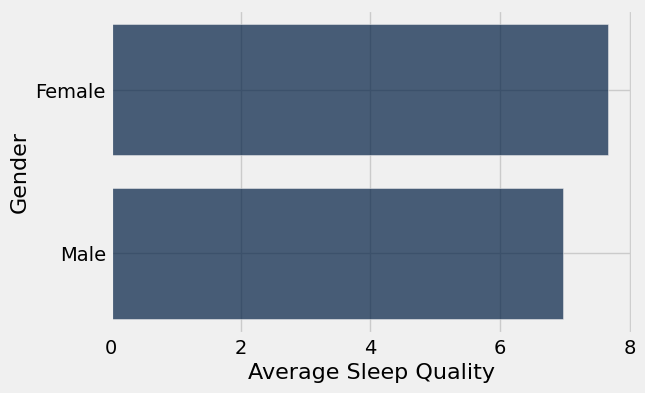

In [39]:
sleep_stats_table.barh('Gender')

In [40]:
stress_stats_table = Table().with_columns(
    'Gender', ['Female', 'Male'],
    'Stress Level', [stress_filter_female, stress_filter_male]
)
stress_stats_table

Gender,Stress Level
Female,4.67568
Male,6.07937


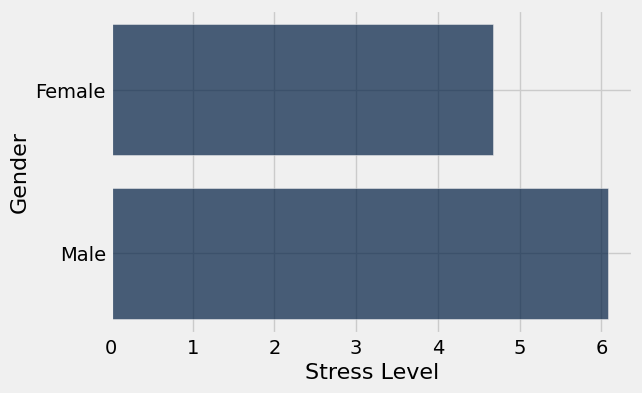

In [41]:
stress_stats_table.barh('Gender')

# Question 3: **How do the stress levels compare between STEM jobs and those who are not?**


In [42]:
stress_table = table_data.select('Occupation', 'Stress Level')
stress_table

Occupation,Stress Level
Software Engineer,6
Doctor,8
Doctor,8
Sales Representative,8
Sales Representative,8
Software Engineer,8
Teacher,7
Doctor,6
Doctor,6
Doctor,6


In [43]:
stem_jobs = table_data.where('Occupation', are.contained_in(['Software Engineer', 'Engineer', 'Doctor', 'Nurse', 'Scientist']))
stem_jobs_stress_level = stem_jobs.select('Occupation', 'Stress Level')

non_stem_jobs = table_data.where('Occupation', are.not_contained_in(['Software Engineer', 'Engineer', 'Doctor', 'Nurse', 'Scientist']))
non_stem_jobs_stress_level = non_stem_jobs.select('Occupation', 'Stress Level')

In [44]:
stem_stress_stress  = np.average(stem_jobs_stress_level.column('Stress Level'))
non_stem_stress = np.average(non_stem_jobs_stress_level.column('Stress Level'))

In [45]:
non_stem_stem_table = Table().with_columns(
    'Occupations', ['STEM Jobs', 'Non-STEM Jobs'],
    'Stress Level Average', [stem_stress_stress, non_stem_stress]
)
non_stem_stem_table

Occupations,Stress Level Average
STEM Jobs,5.48837
Non-STEM Jobs,5.24528


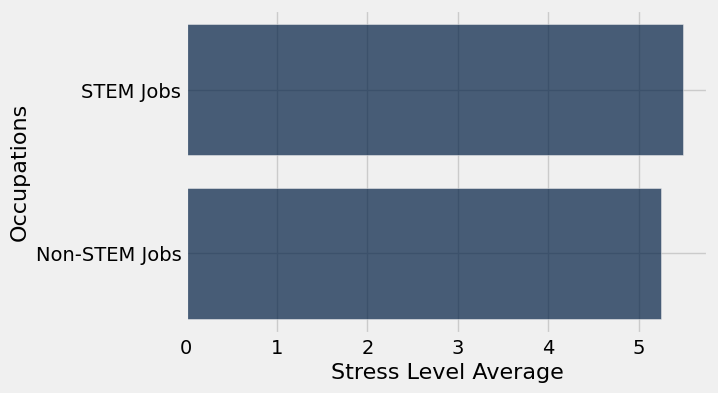

In [46]:
non_stem_stem_table.barh('Occupations')

# **Estimation**


In [61]:
tbl = table_data.select('Occupation', 'Stress Level')
tbl

Occupation,Stress Level
Software Engineer,6
Doctor,8
Doctor,8
Sales Representative,8
Sales Representative,8
Software Engineer,8
Teacher,7
Doctor,6
Doctor,6
Doctor,6


# **Estimation: STEM Stress Levels**

In [62]:
tbl_stem = tbl.where('Occupation', are.contained_in(['Software Engineer', 'Engineer', 'Doctor', 'Nurse', 'Scientist']))
tbl_stem

Occupation,Stress Level
Software Engineer,6
Doctor,8
Doctor,8
Software Engineer,8
Doctor,6
Doctor,6
Doctor,6
Doctor,8
Doctor,6
Doctor,8


sample mean= 5.48837209302


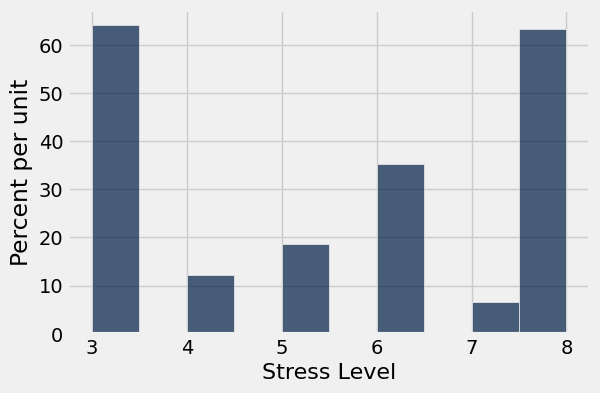

In [63]:
# plot histogram of a variable of interest and calculate a sample estimate of interest
tbl_stem.hist('Stress Level')
my_variable = tbl_stem.column('Stress Level')
my_estimate = np.mean(my_variable)  # update
print ('sample mean=',my_estimate) # update

### 2. Quantify Uncertainty of  Sample Esimate using Boostrapping (95% Confidence Interval )

In [64]:
def one_bootstrap():
    single_sample = tbl_stem.sample()
    return np.mean(single_sample.column('Stress Level'))
one_bootstrap()

5.4604651162790701

In [65]:
bootstrap_result = make_array()
for i in np.arange(1000):
    new_estimate = one_bootstrap()
    bootstrap_result = np.append(bootstrap_result, new_estimate)
bootstrap_result

array([ 5.4744186 ,  5.51162791,  5.57674419,  5.63255814,  5.51162791,
        5.60930233,  5.61860465,  5.41860465,  5.50697674,  5.37674419,
        5.73953488,  5.44651163,  5.28372093,  5.53488372,  5.38139535,
        5.30232558,  5.1255814 ,  5.45581395,  5.50232558,  5.58604651,
        5.59534884,  5.54883721,  5.32093023,  5.40465116,  5.53488372,
        5.50697674,  5.4       ,  5.51162791,  5.55813953,  5.53953488,
        5.64186047,  5.22790698,  5.3627907 ,  5.4372093 ,  5.45116279,
        5.41860465,  5.40930233,  5.84651163,  5.6372093 ,  5.34883721,
        5.55813953,  5.53023256,  5.3255814 ,  5.3255814 ,  5.50232558,
        5.3627907 ,  5.42325581,  5.65581395,  5.54883721,  5.51627907,
        5.46976744,  5.5627907 ,  5.61395349,  5.52093023,  5.60930233,
        5.39534884,  5.32093023,  5.52093023,  5.56744186,  5.14418605,
        5.40465116,  5.32093023,  5.61395349,  5.6372093 ,  5.43255814,
        5.75813953,  5.44186047,  5.50232558,  5.51627907,  5.28

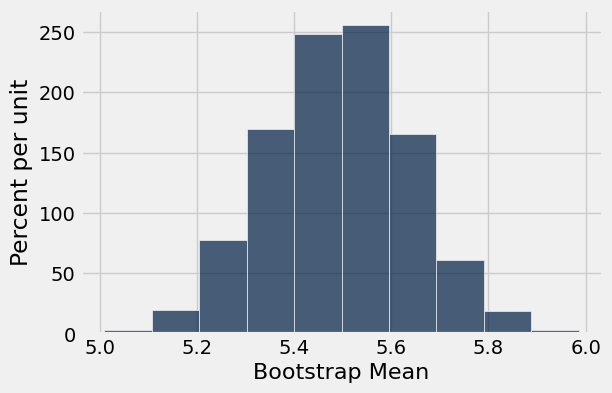

In [66]:
Table().with_column('Bootstrap Mean', bootstrap_result).hist('Bootstrap Mean')

In [67]:
#95% Confidence Interval
print('95% Confidence Interval of Sample Mean')
percentile(2.5, bootstrap_result), percentile(97.5, bootstrap_result)

95% Confidence Interval of Sample Mean


(5.2093023255813957, 5.786046511627907)

### 3. Quantify Uncertainty of  Sample Mean using Central Limit Theorem (95% Confidence Interval )

In [68]:
sample_mean = np.mean(tbl_stem.column('Stress Level'))
sample_size = tbl_stem.num_rows
sample_std = np.std(tbl_stem.column('Stress Level'))

stderr = sample_std/np.sqrt(sample_size)
upper_CI = sample_mean + 1.96 * stderr
lower_CI = sample_mean - 1.96 * stderr
print('95% Confidence Interval of Sample Mean')
lower_CI, upper_CI

95% Confidence Interval of Sample Mean


(5.2125054552226526, 5.764238730823859)

# **Estimation: Non-STEM Stress Levels**

In [72]:
tbl_non_stem = tbl.where('Occupation', are.not_contained_in(['Software Engineer', 'Engineer', 'Doctor', 'Nurse', 'Scientist']))
tbl_non_stem

Occupation,Stress Level
Sales Representative,8
Sales Representative,8
Teacher,7
Accountant,6
Teacher,5
Teacher,5
Accountant,4
Lawyer,5
Accountant,4
Accountant,4


sample mean= 5.24528301887


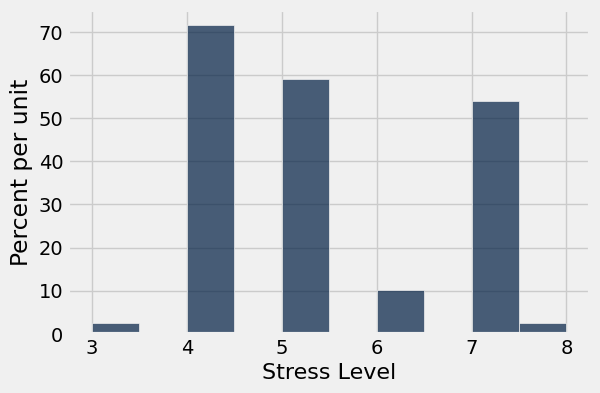

In [73]:
# plot histogram of a variable of interest and calculate a sample estimate of interest
tbl_non_stem.hist('Stress Level')
my_variable = tbl_non_stem.column('Stress Level')
my_estimate = np.mean(my_variable)  # update
print ('sample mean=',my_estimate) # update

### 2. Quantify Uncertainty of  Sample Esimate using Boostrapping (95% Confidence Interval )

In [74]:
def one_bootstrap():
    single_sample = tbl_non_stem.sample()
    return np.mean(single_sample.column('Stress Level'))
one_bootstrap()

5.3836477987421381

In [75]:
bootstrap_result = make_array()
for i in np.arange(1000):
    new_estimate = one_bootstrap()
    bootstrap_result = np.append(bootstrap_result, new_estimate)
bootstrap_result

array([ 5.10062893,  5.1509434 ,  5.10062893,  5.1509434 ,  5.29559748,
        5.26415094,  5.24528302,  5.05660377,  5.28930818,  5.43396226,
        5.0754717 ,  5.18238994,  5.19496855,  5.28930818,  5.06289308,
        5.1572327 ,  5.28301887,  5.26415094,  5.17610063,  5.3836478 ,
        5.24528302,  5.17610063,  5.19496855,  5.11949686,  5.23899371,
        5.25786164,  5.27044025,  5.16981132,  5.27044025,  5.27672956,
        5.34591195,  5.11320755,  5.16981132,  5.37106918,  5.27672956,
        5.39622642,  5.19496855,  5.22641509,  5.35849057,  5.24528302,
        5.31446541,  5.35220126,  5.27044025,  5.18867925,  5.32075472,
        5.11320755,  5.25786164,  5.31446541,  5.41509434,  5.30188679,
        5.01257862,  5.20125786,  5.16352201,  5.30188679,  5.38993711,
        5.43396226,  5.3081761 ,  5.32075472,  5.26415094,  5.16981132,
        5.23899371,  5.33333333,  5.45283019,  5.21383648,  5.10691824,
        5.35220126,  5.17610063,  5.27672956,  5.28930818,  5.25

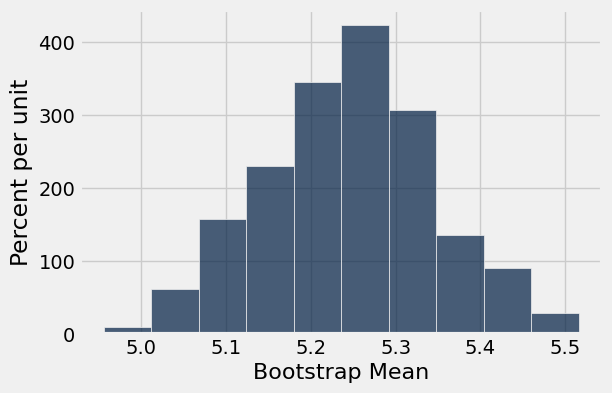

In [76]:
Table().with_column('Bootstrap Mean', bootstrap_result).hist('Bootstrap Mean')

In [77]:
#95% Confidence Interval
print('95% Confidence Interval of Sample Mean')
percentile(2.5, bootstrap_result), percentile(97.5, bootstrap_result)

95% Confidence Interval of Sample Mean


(5.050314465408805, 5.4339622641509431)

### 3. Quantify Uncertainty of  Sample Mean using Central Limit Theorem (95% Confidence Interval )

In [78]:
sample_mean = np.mean(tbl_non_stem.column('Stress Level'))
sample_size = tbl_non_stem.num_rows
sample_std = np.std(tbl_non_stem.column('Stress Level'))

stderr = sample_std/np.sqrt(sample_size)
upper_CI = sample_mean + 1.96 * stderr
lower_CI = sample_mean - 1.96 * stderr
print('95% Confidence Interval of Sample Mean')
lower_CI, upper_CI

95% Confidence Interval of Sample Mean


(5.0490412933893829, 5.4415247443464665)